# Train Logistic Regression on Sign Count Concepts

This notebook trains a multivariate logistic-regression classifier on the sample-level TCAV `sign_count` concept vectors.
It uses an 80/20 split over shared speakers inside each `system_id`, so spoof and bonafide remain paired per system while avoiding speaker leakage.


In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler


In [ ]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')
TCAV_ROOT = PROJECT_ROOT / 'resnet_293' / 'tcav' / 'captum_tcav' / 'asvspoof5'
OUTPUT_SUBDIR = 'subset_20spk_20utts_per_spk_one_logistic_head'
OUTPUT_DIR = TCAV_ROOT / 'output' / OUTPUT_SUBDIR

INPUT_CSV = OUTPUT_DIR / "merged_tcav_sign_count_speaker_level.csv"
MODEL_OUT_DIR = OUTPUT_DIR / 'sign_count_logistic_results_speaker_level'
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE_A12 = True
TEST_FRACTION = 0.2
RANDOM_SEED = 42
LOGREG_MAX_ITER = 2000
LOGREG_C = 1.0

print('INPUT_CSV =', INPUT_CSV)
print('Exists =', INPUT_CSV.exists())
print('MODEL_OUT_DIR =', MODEL_OUT_DIR)

INPUT_CSV = /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/merged_tcav_sign_count_speaker_level.csv
Exists = True
MODEL_OUT_DIR = /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/sign_count_logistic_results_speaker_level


In [3]:
df = pd.read_csv(INPUT_CSV)

if EXCLUDE_A12:
    df = df[df['system_id'] != 'A12'].copy()

meta_cols = [ 'speaker_id', 'split', 'source_partition', 'system_id', 'target_class', 'binary_label']
feature_cols = [c for c in df.columns if c not in meta_cols]

print('Rows =', len(df))
print('Speakers =', df['speaker_id'].nunique())
print('Systems =', sorted(df['system_id'].unique().tolist()))
print('Feature columns =', len(feature_cols))
display(df.head())


Rows = 600
Speakers = 81
Systems = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A13', 'A14', 'A15', 'A16']
Feature columns = 13


,speaker_id,split,source_partition,system_id,target_class,binary_label,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin,n_utterances
0,D_0430,test,dev,A09,bonafide,0,0.85,0.85,0.75,0.90,0.95,0.90,0.85,0.85,0.90,0.85,0.85,0.80,20
1,D_0461,test,dev,A09,bonafide,0,0.70,0.95,0.75,0.85,0.60,0.60,0.85,0.80,0.85,0.55,0.85,0.80,20
2,D_0546,test,dev,A09,bonafide,0,0.20,0.25,0.20,0.25,0.45,0.45,0.30,0.20,0.35,0.15,0.40,0.35,20
3,D_0956,test,dev,A09,bonafide,0,0.15,0.25,0.10,0.20,0.25,0.25,0.20,0.15,0.25,0.15,0.20,0.15,20
4,D_2327,test,dev,A09,bonafide,0,0.40,0.70,0.45,0.50,0.55,0.50,0.80,0.50,0.55,0.25,0.55,0.55,20


In [4]:
rng = np.random.default_rng(RANDOM_SEED)
train_parts = []
test_parts = []
split_summary_rows = []

for system_id in sorted(df['system_id'].unique()):
    sys_df = df[df['system_id'] == system_id].copy()
    spoof_speakers = set(sys_df.loc[sys_df['target_class'] == 'spoof', 'speaker_id'].unique().tolist())
    bonafide_speakers = set(sys_df.loc[sys_df['target_class'] == 'bonafide', 'speaker_id'].unique().tolist())
    shared_speakers = np.array(sorted(spoof_speakers.intersection(bonafide_speakers)), dtype=object)

    if len(shared_speakers) < 2:
        raise RuntimeError(f'Not enough shared speakers for system {system_id}: {len(shared_speakers)}')

    rng.shuffle(shared_speakers)
    n_test = max(1, int(round(len(shared_speakers) * TEST_FRACTION)))
    if n_test >= len(shared_speakers):
        n_test = len(shared_speakers) - 1

    test_speakers = set(shared_speakers[:n_test].tolist())
    train_speakers = set(shared_speakers[n_test:].tolist())

    sys_train_df = sys_df[sys_df['speaker_id'].isin(train_speakers)].copy()
    sys_test_df = sys_df[sys_df['speaker_id'].isin(test_speakers)].copy()

    train_parts.append(sys_train_df)
    test_parts.append(sys_test_df)

    split_summary_rows.append({
        'system_id': system_id,
        'shared_speakers_total': int(len(shared_speakers)),
        'train_speakers': int(len(train_speakers)),
        'test_speakers': int(len(test_speakers)),
        'train_rows': int(len(sys_train_df)),
        'test_rows': int(len(sys_test_df)),
        'train_spoof_rows': int((sys_train_df['binary_label'] == 1).sum()),
        'train_bonafide_rows': int((sys_train_df['binary_label'] == 0).sum()),
        'test_spoof_rows': int((sys_test_df['binary_label'] == 1).sum()),
        'test_bonafide_rows': int((sys_test_df['binary_label'] == 0).sum()),
    })

split_check_df = pd.DataFrame(split_summary_rows).sort_values('system_id').reset_index(drop=True)
display(split_check_df)

train_df = pd.concat(train_parts, axis=0, ignore_index=True)
test_df = pd.concat(test_parts, axis=0, ignore_index=True)

train_keys = set(zip(train_df['system_id'], train_df['speaker_id']))
test_keys = set(zip(test_df['system_id'], test_df['speaker_id']))
assert train_keys.isdisjoint(test_keys), 'System-speaker leakage detected'

print('Train rows =', len(train_df))
print('Test rows =', len(test_df))
print('Train class counts:')
print(train_df['binary_label'].value_counts().sort_index())
print('Test class counts:')
print(test_df['binary_label'].value_counts().sort_index())


,system_id,shared_speakers_total,train_speakers,test_speakers,train_rows,test_rows,train_spoof_rows,train_bonafide_rows,test_spoof_rows,test_bonafide_rows
0,A01,20,16,4,32,8,16,16,4,4
1,A02,20,16,4,32,8,16,16,4,4
2,A03,20,16,4,32,8,16,16,4,4
3,A04,20,16,4,32,8,16,16,4,4
4,A05,20,16,4,32,8,16,16,4,4
5,A06,20,16,4,32,8,16,16,4,4
6,A07,20,16,4,32,8,16,16,4,4
7,A08,20,16,4,32,8,16,16,4,4
8,A09,20,16,4,32,8,16,16,4,4
9,A10,20,16,4,32,8,16,16,4,4


Train rows = 480
Test rows = 120
Train class counts:
0    240
1    240
Name: binary_label, dtype: int64
Test class counts:
0    60
1    60
Name: binary_label, dtype: int64


In [5]:
X_tr = train_df[feature_cols].to_numpy(dtype=float)
y_tr = train_df['binary_label'].to_numpy(dtype=int)
X_te = test_df[feature_cols].to_numpy(dtype=float)
y_te = test_df['binary_label'].to_numpy(dtype=int)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf = LogisticRegression(
    max_iter=LOGREG_MAX_ITER,
    C=LOGREG_C,
    class_weight=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
clf.fit(X_tr_s, y_tr)

p_tr = clf.predict_proba(X_tr_s)[:, 1]
p_te = clf.predict_proba(X_te_s)[:, 1]
yhat_tr = (p_tr >= 0.5).astype(int)
yhat_te = (p_te >= 0.5).astype(int)

summary = {
    'train_accuracy': float(accuracy_score(y_tr, yhat_tr)),
    'test_accuracy': float(accuracy_score(y_te, yhat_te)),
    'train_auc': float(roc_auc_score(y_tr, p_tr)),
    'test_auc': float(roc_auc_score(y_te, p_te)),
    'train_confusion_matrix': confusion_matrix(y_tr, yhat_tr).tolist(),
    'test_confusion_matrix': confusion_matrix(y_te, yhat_te).tolist(),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'train_speakers': int(train_df[['system_id', 'speaker_id']].drop_duplicates().shape[0]),
    'test_speakers': int(test_df[['system_id', 'speaker_id']].drop_duplicates().shape[0]),
    'split_strategy': 'per_system_shared_speakers',
    'feature_dim': int(len(feature_cols)),
}

print(json.dumps(summary, indent=2))


{
  "train_accuracy": 0.6020833333333333,
  "test_accuracy": 0.6166666666666667,
  "train_auc": 0.6877430555555555,
  "test_auc": 0.7220833333333334,
  "train_confusion_matrix": [
    [
      116,
      124
    ],
    [
      67,
      173
    ]
  ],
  "test_confusion_matrix": [
    [
      24,
      36
    ],
    [
      10,
      50
    ]
  ],
  "train_rows": 480,
  "test_rows": 120,
  "train_speakers": 240,
  "test_speakers": 60,
  "split_strategy": "per_system_shared_speakers",
  "feature_dim": 13
}


,split,accuracy,auc,rows,speakers
0,train,0.602083,0.687743,480,240
1,test,0.616667,0.722083,120,60


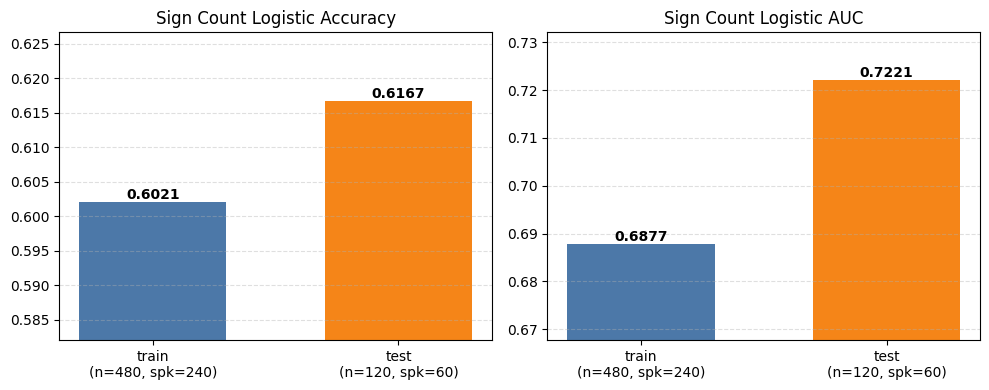

In [6]:
summary_df = pd.DataFrame([
    {
        'split': 'train',
        'accuracy': summary['train_accuracy'],
        'auc': summary['train_auc'],
        'rows': summary['train_rows'],
        'speakers': summary['train_speakers'],
    },
    {
        'split': 'test',
        'accuracy': summary['test_accuracy'],
        'auc': summary['test_auc'],
        'rows': summary['test_rows'],
        'speakers': summary['test_speakers'],
    },
])
display(summary_df)

plot_df = summary_df.copy()
plot_df['label'] = plot_df.apply(lambda r: f"{r['split']}\n(n={int(r['rows'])}, spk={int(r['speakers'])})", axis=1)

metrics = [('accuracy', 'Accuracy'), ('auc', 'AUC')]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (metric, title) in zip(axes, metrics):
    vals = plot_df[metric].astype(float).to_numpy()
    labels = plot_df['label'].tolist()
    ymin = max(0.0, vals.min() - 0.02)
    ymax = min(1.0, vals.max() + 0.01)
    if ymax - ymin < 0.02:
        ymin = max(0.0, vals.min() - 0.01)
        ymax = min(1.0, vals.max() + 0.01)
    bars = ax.bar(labels, vals, color=['#4C78A8', '#F58518'], width=0.6)
    ax.set_title(f'Sign Count Logistic {title}')
    ax.set_ylim(ymin, ymax)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
coef_df = pd.DataFrame({
    'concept': feature_cols,
    'coef': clf.coef_[0],
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Intercept:', float(clf.intercept_[0]))
display(coef_df)
display(coef_df.head(10))


Intercept: -0.02277572679026453


,concept,coef,abs_coef
0,short_constant_thick,1.474107,1.474107
1,long_rising_flat_thick,0.994881,0.994881
2,short_dropping_steep_thick,-0.869433,0.869433
3,long_constant_thick,-0.817744,0.817744
4,long_dropping_flat_thick,-0.745925,0.745925
5,long_rising_steep_thick,0.638823,0.638823
6,long_dropping_steep_thick,0.595392,0.595392
7,long_dropping_steep_thin,-0.517347,0.517347
8,long_rising_steep_thin,-0.275230,0.275230
9,short_rising_steep_thin,-0.107382,0.107382


,concept,coef,abs_coef
0,short_constant_thick,1.474107,1.474107
1,long_rising_flat_thick,0.994881,0.994881
2,short_dropping_steep_thick,-0.869433,0.869433
3,long_constant_thick,-0.817744,0.817744
4,long_dropping_flat_thick,-0.745925,0.745925
5,long_rising_steep_thick,0.638823,0.638823
6,long_dropping_steep_thick,0.595392,0.595392
7,long_dropping_steep_thin,-0.517347,0.517347
8,long_rising_steep_thin,-0.275230,0.275230
9,short_rising_steep_thin,-0.107382,0.107382


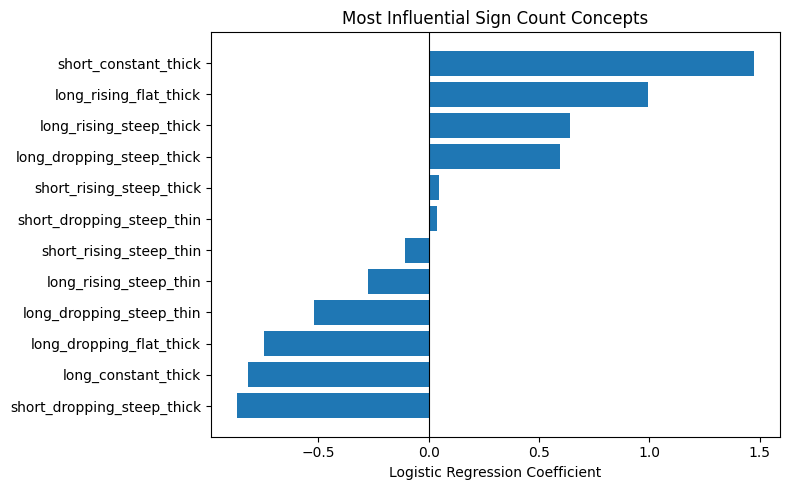

In [8]:
top_df = coef_df.head(12).copy().sort_values('coef')
plt.figure(figsize=(8, 5))
# colors = ['#D62728' if v < 0 else '#2CA02C' for v in top_df['coef']]
plt.barh(top_df['concept'], top_df['coef'] )# color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Most Influential Sign Count Concepts')
plt.xlabel('Logistic Regression Coefficient')
plt.tight_layout()
plt.show()


In [9]:
with open(MODEL_OUT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(MODEL_OUT_DIR / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open(MODEL_OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

coef_df.to_csv(MODEL_OUT_DIR / 'coefficients.csv', index=False)
train_df.to_csv(MODEL_OUT_DIR / 'train_split.csv', index=False)
test_df.to_csv(MODEL_OUT_DIR / 'test_split.csv', index=False)

pred_train = train_df[meta_cols].copy()
pred_train['p_spoof'] = p_tr
pred_train['y_hat'] = yhat_tr
pred_train['split_role'] = 'train'

pred_test = test_df[meta_cols].copy()
pred_test['p_spoof'] = p_te
pred_test['y_hat'] = yhat_te
pred_test['split_role'] = 'test'

pred_df = pd.concat([pred_train, pred_test], axis=0, ignore_index=True)
pred_df.to_csv(MODEL_OUT_DIR / 'predictions.csv', index=False)
split_check_df.to_csv(MODEL_OUT_DIR / 'split_check.csv', index=False)

print('Saved outputs to:', MODEL_OUT_DIR)


Saved outputs to: /home/SpeakerRec/BioVoice/redimnet/tcav/captum_tcav/asvspoof5/output/subset_20spk_20utts_per_spk_one_logistic_head/sign_count_logistic_results_speaker_level


## Extra Analysis

These cells help inspect which systems are easy or hard, where the model makes its biggest mistakes, and which concepts differ most between spoof and bonafide per system.


In [10]:
test_analysis_df = pred_df[pred_df['split_role'] == 'test'].copy()
test_analysis_df['is_correct'] = (test_analysis_df['binary_label'] == test_analysis_df['y_hat']).astype(int)
test_analysis_df['error_type'] = 'correct'
test_analysis_df.loc[(test_analysis_df['binary_label'] == 0) & (test_analysis_df['y_hat'] == 1), 'error_type'] = 'false_positive'
test_analysis_df.loc[(test_analysis_df['binary_label'] == 1) & (test_analysis_df['y_hat'] == 0), 'error_type'] = 'false_negative'

system_metrics = []
for system_id, sub in test_analysis_df.groupby('system_id'):
    y_true_sys = sub['binary_label'].to_numpy()
    y_hat_sys = sub['y_hat'].to_numpy()
    p_sys = sub['p_spoof'].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true_sys, y_hat_sys).ravel()
    system_metrics.append({
        'system_id': system_id,
        'rows': int(len(sub)),
        'accuracy': float(accuracy_score(y_true_sys, y_hat_sys)),
        'auc': float(roc_auc_score(y_true_sys, p_sys)),
        'bonafide_rows': int((sub['binary_label'] == 0).sum()),
        'spoof_rows': int((sub['binary_label'] == 1).sum()),
        'true_negative': int(tn),
        'false_positive': int(fp),
        'false_negative': int(fn),
        'true_positive': int(tp),
        'fpr': float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        'fnr': float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    })

system_metrics_df = pd.DataFrame(system_metrics).sort_values(['accuracy', 'auc'], ascending=[False, False]).reset_index(drop=True)
display(system_metrics_df)


,system_id,rows,accuracy,auc,bonafide_rows,spoof_rows,true_negative,false_positive,false_negative,true_positive,fpr,fnr
0,A02,8,0.875,0.90625,4,4,3,1,0,4,0.25,0.00
1,A10,8,0.750,1.00000,4,4,2,2,0,4,0.50,0.00
2,A15,8,0.750,0.96875,4,4,2,2,0,4,0.50,0.00
3,A14,8,0.750,0.93750,4,4,3,1,1,3,0.25,0.25
4,A08,8,0.750,0.81250,4,4,2,2,0,4,0.50,0.00
5,A05,8,0.750,0.75000,4,4,2,2,0,4,0.50,0.00
6,A03,8,0.750,0.65625,4,4,2,2,0,4,0.50,0.00
7,A01,8,0.625,0.62500,4,4,1,3,0,4,0.75,0.00
8,A09,8,0.625,0.62500,4,4,2,2,1,3,0.50,0.25
9,A07,8,0.500,0.87500,4,4,0,4,0,4,1.00,0.00


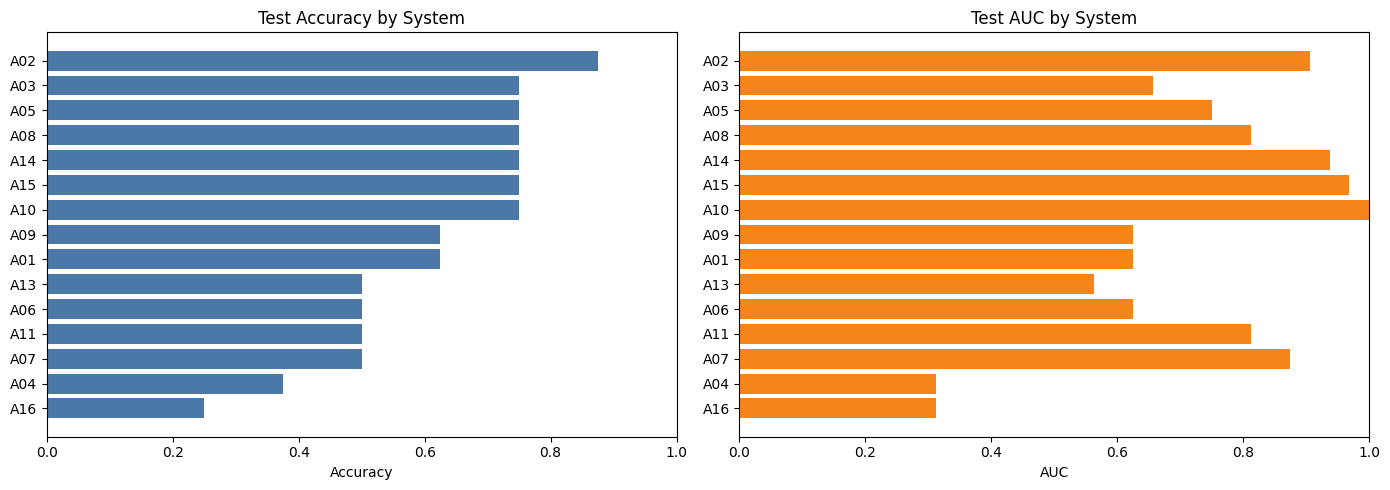

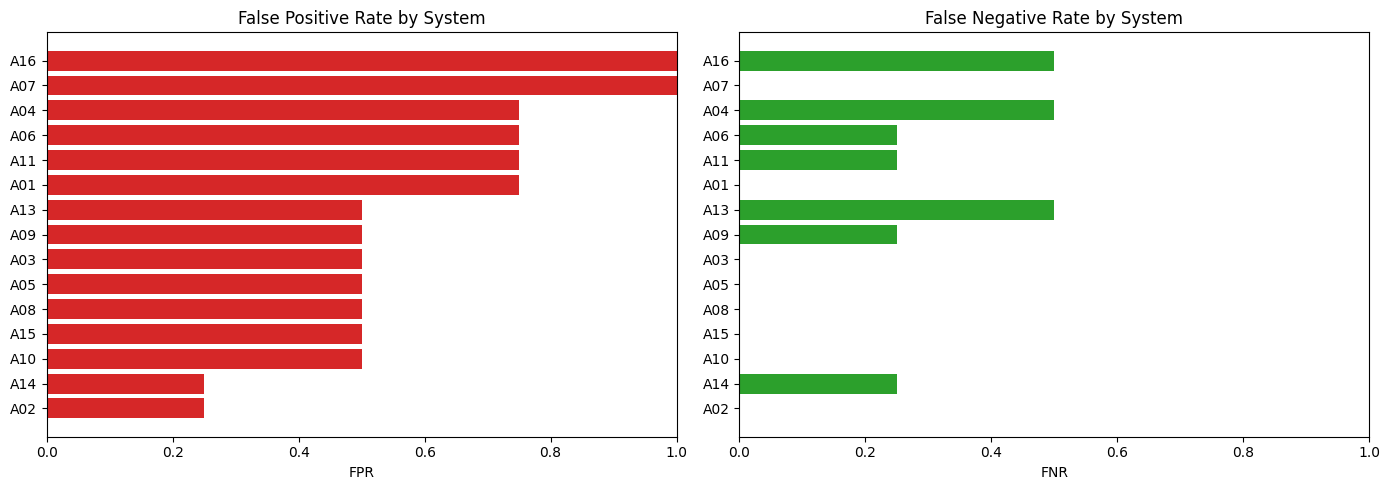

In [11]:
plot_df = system_metrics_df.sort_values('accuracy').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(plot_df['system_id'], plot_df['accuracy'], color='#4C78A8')
axes[0].set_title('Test Accuracy by System')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Accuracy')

axes[1].barh(plot_df['system_id'], plot_df['auc'], color='#F58518')
axes[1].set_title('Test AUC by System')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('AUC')
plt.tight_layout()
plt.show()

err_df = system_metrics_df.sort_values('fpr').reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(err_df['system_id'], err_df['fpr'], color='#D62728')
axes[0].set_title('False Positive Rate by System')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('FPR')

axes[1].barh(err_df['system_id'], err_df['fnr'], color='#2CA02C')
axes[1].set_title('False Negative Rate by System')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('FNR')
plt.tight_layout()
plt.show()


In [12]:
false_pos_df = test_analysis_df[test_analysis_df['error_type'] == 'false_positive'].copy()
false_pos_df['confidence'] = false_pos_df['p_spoof']
false_pos_df = false_pos_df.sort_values('confidence', ascending=False)

false_neg_df = test_analysis_df[test_analysis_df['error_type'] == 'false_negative'].copy()
false_neg_df['confidence'] = 1.0 - false_neg_df['p_spoof']
false_neg_df = false_neg_df.sort_values('confidence', ascending=False)

print('Most confident false positives:')
display(false_pos_df[['system_id', 'speaker_id',  'target_class', 'binary_label', 'p_spoof', 'y_hat']].head(20))

print('Most confident false negatives:')
display(false_neg_df[['system_id', 'speaker_id',  'target_class', 'binary_label', 'p_spoof', 'y_hat']].head(20))


Most confident false positives:


,system_id,speaker_id,target_class,binary_label,p_spoof,y_hat
594,A16,D_4825,bonafide,0,0.644023,1
563,A11,D_4825,bonafide,0,0.644023,1
546,A09,D_4825,bonafide,0,0.644023,1
504,A04,T_0571,bonafide,0,0.642317,1
523,A06,T_5284,bonafide,0,0.622343,1
536,A08,T_2182,bonafide,0,0.617667,1
547,A09,D_5112,bonafide,0,0.599072,1
587,A15,D_4888,bonafide,0,0.597246,1
537,A08,T_2211,bonafide,0,0.597246,1
481,A01,T_2791,bonafide,0,0.597246,1


Most confident false negatives:


,system_id,speaker_id,target_class,binary_label,p_spoof,y_hat
524,A06,T_0554,spoof,1,0.169387,0
598,A16,D_4825,spoof,1,0.220729,0
574,A13,D_3501,spoof,1,0.271066,0
573,A13,D_2968,spoof,1,0.287530,0
549,A09,D_4814,spoof,1,0.312481,0
508,A04,T_0571,spoof,1,0.376927,0
582,A14,D_2991,spoof,1,0.442978,0
567,A11,D_4825,spoof,1,0.445583,0
597,A16,D_3501,spoof,1,0.458575,0
511,A04,T_4913,spoof,1,0.472147,0


,long_constant_thick,long_dropping_flat_thick,long_dropping_steep_thick,long_dropping_steep_thin,long_rising_flat_thick,long_rising_steep_thick,long_rising_steep_thin,short_constant_thick,short_dropping_steep_thick,short_dropping_steep_thin,short_rising_steep_thick,short_rising_steep_thin,n_utterances
A01,0.0750,8.750000e-02,0.1000,0.0750,0.0875,3.750000e-02,0.0875,0.0750,0.0875,0.0750,0.0625,0.0625,0.0
A02,0.3250,2.625000e-01,0.3125,0.2500,0.3375,2.875000e-01,0.2500,0.3125,0.3000,0.3250,0.2375,0.2750,0.0
A03,0.3750,2.500000e-01,0.3000,0.3375,0.3250,2.250000e-01,0.3125,0.3375,0.3625,0.3500,0.2500,0.2875,0.0
A04,-0.0500,-7.500000e-02,-0.0875,-0.1250,-0.0625,-1.125000e-01,-0.2125,-0.1125,-0.1000,-0.1875,-0.0875,-0.0625,0.0
A05,0.2375,2.125000e-01,0.2375,0.1500,0.2000,2.375000e-01,0.1750,0.2000,0.1625,0.1500,0.1750,0.2375,0.0
A06,0.0750,1.110223e-16,0.0500,-0.0125,0.0375,1.110223e-16,0.0375,0.0625,0.0500,-0.0375,0.0000,0.0500,0.0
A07,0.0125,0.000000e+00,0.0250,0.0125,0.0375,-1.250000e-02,0.0375,0.0250,0.0250,0.0125,-0.0125,0.0125,0.0
A08,0.0750,5.000000e-02,0.1000,0.0750,0.1125,7.500000e-02,0.0750,0.1000,0.0625,0.1125,0.1000,0.0500,0.0
A09,0.0250,-3.750000e-02,0.0000,0.0125,0.0125,-1.250000e-02,-0.0250,0.0500,0.0500,0.0625,0.0125,0.0250,0.0
A10,0.2875,2.750000e-01,0.2750,0.3500,0.3250,2.750000e-01,0.2625,0.3000,0.2375,0.2250,0.2375,0.2250,0.0


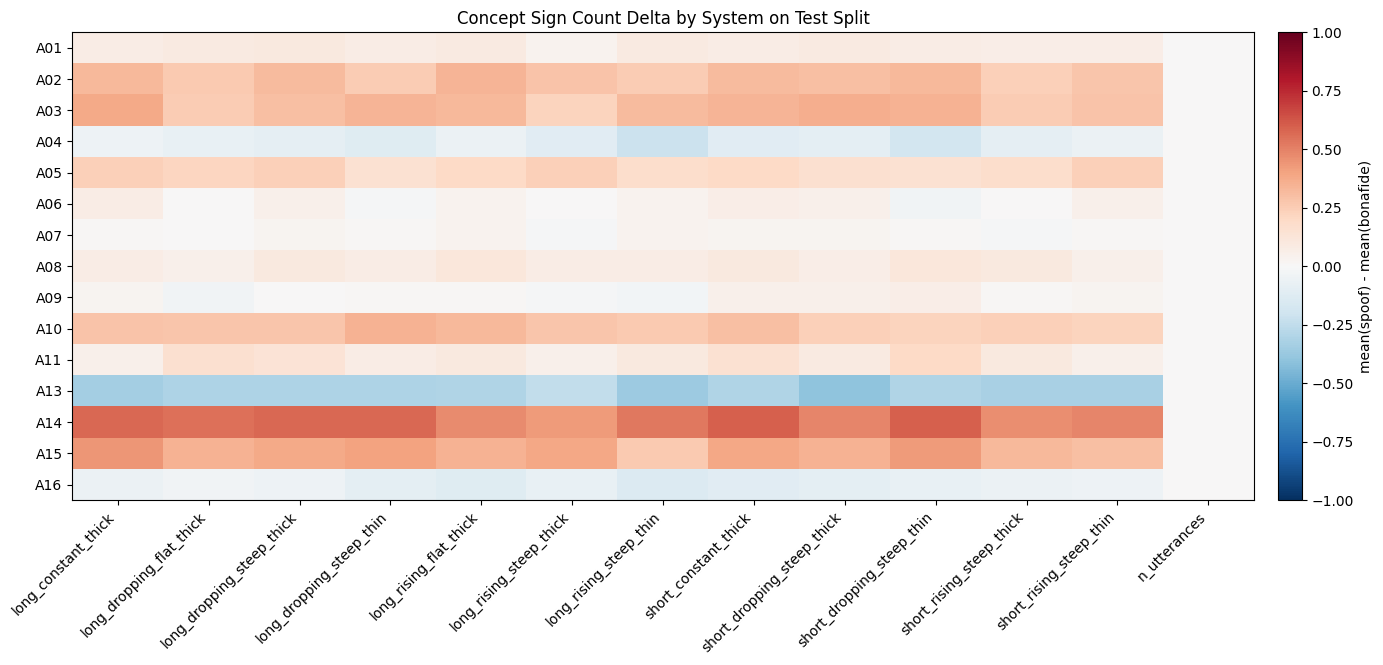

In [13]:
delta_rows = []
for system_id, sub in test_df.groupby('system_id'):
    spoof_mean = sub.loc[sub['binary_label'] == 1, feature_cols].mean()
    bonafide_mean = sub.loc[sub['binary_label'] == 0, feature_cols].mean()
    delta_rows.append((system_id, (spoof_mean - bonafide_mean).to_dict()))

system_delta_df = pd.DataFrame({system_id: vals for system_id, vals in delta_rows}).T[feature_cols]
display(system_delta_df)

plt.figure(figsize=(14, max(5, len(system_delta_df) * 0.45)))
im = plt.imshow(system_delta_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.02, pad=0.02, label='mean(spoof) - mean(bonafide)')
plt.yticks(range(len(system_delta_df.index)), system_delta_df.index)
plt.xticks(range(len(system_delta_df.columns)), system_delta_df.columns, rotation=45, ha='right')
plt.title('Concept Sign Count Delta by System on Test Split')
plt.tight_layout()
plt.show()


## Overall Accuracy (Train + Test Combined)

Evaluate the logistic-regression model on all data (train + test) together.


In [14]:
# ===== Overall accuracy on combined train + test =====
y_all = np.concatenate([y_tr, y_te])
yhat_all = np.concatenate([yhat_tr, yhat_te])
p_all = np.concatenate([p_tr, p_te])

overall_acc = accuracy_score(y_all, yhat_all)
overall_auc = roc_auc_score(y_all, p_all)
overall_cm = confusion_matrix(y_all, yhat_all)

print(f'Overall Accuracy (train + test combined): {overall_acc:.4f}')
print(f'Overall AUC (train + test combined):      {overall_auc:.4f}')
print(f'Total samples: {len(y_all)}  (train={len(y_tr)}, test={len(y_te)})')
print()
print('Overall Confusion Matrix:')
print(overall_cm)
print()
print('Overall Classification Report:')
print(classification_report(y_all, yhat_all, target_names=['bonafide', 'spoof']))

# Summary table
overall_summary_df = pd.DataFrame([
    {'split': 'train', 'accuracy': summary['train_accuracy'], 'auc': summary['train_auc'], 'rows': summary['train_rows']},
    {'split': 'test', 'accuracy': summary['test_accuracy'], 'auc': summary['test_auc'], 'rows': summary['test_rows']},
    {'split': 'overall', 'accuracy': overall_acc, 'auc': overall_auc, 'rows': len(y_all)},
])
display(overall_summary_df)


Overall Accuracy (train + test combined): 0.6050
Overall AUC (train + test combined):      0.6922
Total samples: 600  (train=480, test=120)

Overall Confusion Matrix:
[[140 160]
 [ 77 223]]

Overall Classification Report:
              precision    recall  f1-score   support

    bonafide       0.65      0.47      0.54       300
       spoof       0.58      0.74      0.65       300

    accuracy                           0.60       600
   macro avg       0.61      0.60      0.60       600
weighted avg       0.61      0.60      0.60       600



,split,accuracy,auc,rows
0,train,0.602083,0.687743,480
1,test,0.616667,0.722083,120
2,overall,0.605000,0.692183,600


## Per-Concept Threshold Analysis

For each sign-count concept, we ask: **is there a threshold value above which the sample is likely spoof (fake)?**

We use each concept individually as a univariate predictor of spoof vs bonafide, sweep all possible thresholds,
and pick the one that maximises **Youden's J statistic** (= sensitivity + specificity - 1).
This gives the single best operating point for each concept.


In [ ]:
from sklearn.metrics import roc_curve

# Combine train + test for analysis
all_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
y_all_labels = all_df['binary_label'].to_numpy(dtype=int)

# Only analyse actual concept columns (exclude n_utterances)
concept_cols = [c for c in feature_cols if c != 'n_utterances']

threshold_results = []

for concept in concept_cols:
    values = all_df[concept].to_numpy(dtype=float)
    mean_spoof = values[y_all_labels == 1].mean()
    mean_bonafide = values[y_all_labels == 0].mean()

    # Determine direction: higher concept value -> spoof, or lower -> spoof
    if mean_spoof >= mean_bonafide:
        predictor = values          # higher = more likely spoof
        direction = 'above threshold -> spoof'
    else:
        predictor = -values         # flip so roc_curve works correctly
        direction = 'below threshold -> spoof'

    fpr, tpr, thresholds = roc_curve(y_all_labels, predictor)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    raw_threshold = thresholds[best_idx]

    # Convert threshold back to original scale if flipped
    if mean_spoof >= mean_bonafide:
        best_threshold = raw_threshold
        yhat_concept = (values >= best_threshold).astype(int)
    else:
        best_threshold = -raw_threshold
        yhat_concept = (values <= best_threshold).astype(int)

    acc = accuracy_score(y_all_labels, yhat_concept)
    concept_auc = roc_auc_score(y_all_labels, predictor)

    threshold_results.append({
        'concept': concept,
        'optimal_threshold': round(best_threshold, 4),
        'direction': direction,
        'youden_j': round(j_scores[best_idx], 4),
        'accuracy': round(acc, 4),
        'sensitivity': round(tpr[best_idx], 4),
        'specificity': round(1 - fpr[best_idx], 4),
        'auc': round(concept_auc, 4),
        'mean_spoof': round(mean_spoof, 4),
        'mean_bonafide': round(mean_bonafide, 4),
    })

threshold_df = pd.DataFrame(threshold_results).sort_values('youden_j', ascending=False).reset_index(drop=True)
display(threshold_df)

print()
print('Top concepts by Youden J (best separability between spoof and bonafide):')
for _, row in threshold_df.head(5).iterrows():
    print(f"  {row['concept']:35s}  threshold={row['optimal_threshold']:.4f}  "
          f"({row['direction']})  acc={row['accuracy']:.4f}  "
          f"sens={row['sensitivity']:.4f}  spec={row['specificity']:.4f}  "
          f"J={row['youden_j']:.4f}")


Per-Concept Threshold Analysis (combined train + test)
Goal: find a threshold per concept above/below which we can say the sample is fake



,concept,optimal_threshold,direction,youden_j,accuracy,sensitivity,specificity,auc,mean_spoof,mean_bonafide
0,long_rising_flat_thick,0.70,above threshold -> spoof,0.2067,0.6033,0.8433,0.3633,0.6271,0.8603,0.7433
1,short_constant_thick,0.85,above threshold -> spoof,0.2033,0.6017,0.6733,0.5300,0.6352,0.8332,0.7087
2,short_rising_steep_thick,0.90,above threshold -> spoof,0.1933,0.5967,0.7000,0.4933,0.6185,0.8723,0.7753
3,long_dropping_steep_thick,0.85,above threshold -> spoof,0.1900,0.5950,0.6867,0.5033,0.6143,0.8368,0.7215
4,long_rising_steep_thick,0.85,above threshold -> spoof,0.1867,0.5933,0.7467,0.4400,0.6241,0.8653,0.7622
5,long_rising_steep_thin,0.90,above threshold -> spoof,0.1700,0.5850,0.6267,0.5433,0.6042,0.8412,0.7417
6,short_dropping_steep_thin,0.60,above threshold -> spoof,0.1700,0.5850,0.8200,0.3500,0.6072,0.7927,0.6763
7,long_dropping_flat_thick,0.90,above threshold -> spoof,0.1633,0.5817,0.6433,0.5200,0.5985,0.8497,0.7545
8,short_dropping_steep_thick,0.95,above threshold -> spoof,0.1633,0.5817,0.4733,0.6900,0.5989,0.8205,0.7242
9,long_dropping_steep_thin,0.65,above threshold -> spoof,0.1567,0.5783,0.8467,0.3100,0.5961,0.8337,0.7320



Top concepts by Youden J (best separability between spoof and bonafide):
  long_rising_flat_thick               threshold=0.7000  (above threshold -> spoof)  acc=0.6033  sens=0.8433  spec=0.3633  J=0.2067
  short_constant_thick                 threshold=0.8500  (above threshold -> spoof)  acc=0.6017  sens=0.6733  spec=0.5300  J=0.2033
  short_rising_steep_thick             threshold=0.9000  (above threshold -> spoof)  acc=0.5967  sens=0.7000  spec=0.4933  J=0.1933
  long_dropping_steep_thick            threshold=0.8500  (above threshold -> spoof)  acc=0.5950  sens=0.6867  spec=0.5033  J=0.1900
  long_rising_steep_thick              threshold=0.8500  (above threshold -> spoof)  acc=0.5933  sens=0.7467  spec=0.4400  J=0.1867


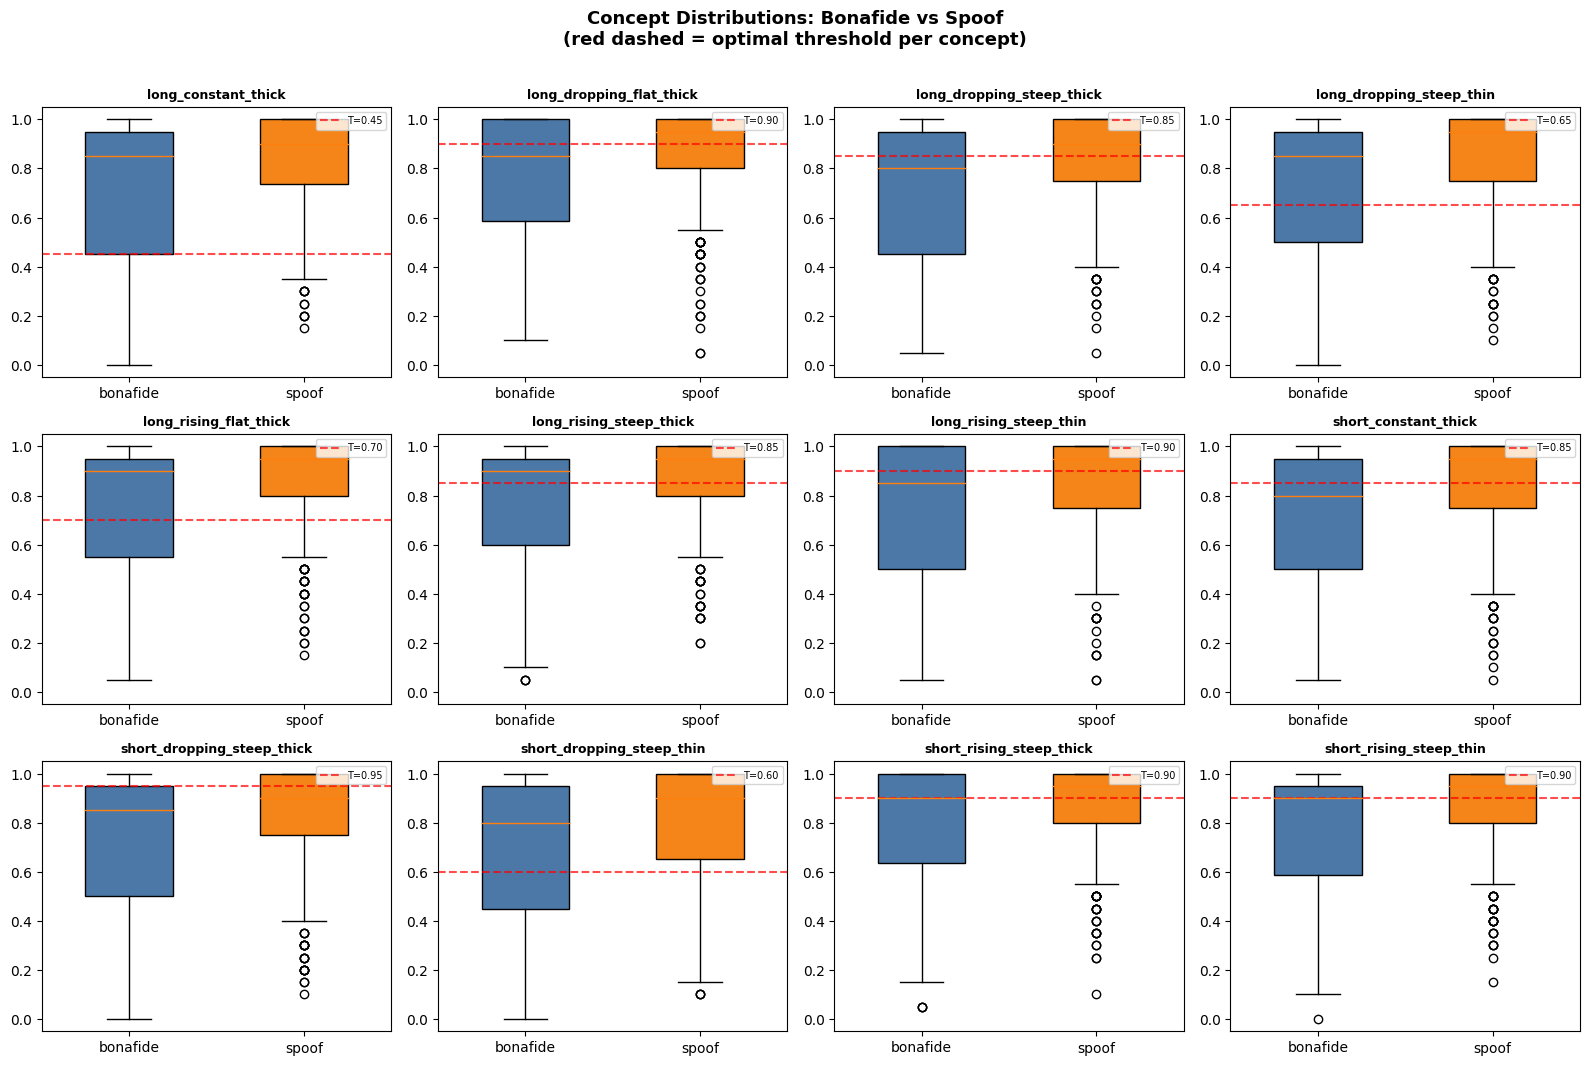

In [16]:
# ===== Box plots: concept value distributions with threshold lines =====
n_concepts = len(concept_cols)
ncols = 4
nrows = (n_concepts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, concept in enumerate(concept_cols):
    ax = axes[i]
    bonafide_vals = all_df.loc[all_df['binary_label'] == 0, concept].values
    spoof_vals = all_df.loc[all_df['binary_label'] == 1, concept].values

    bp = ax.boxplot([bonafide_vals, spoof_vals], labels=['bonafide', 'spoof'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#4C78A8')
    bp['boxes'][1].set_facecolor('#F58518')

    # Draw threshold line
    row = threshold_df[threshold_df['concept'] == concept].iloc[0]
    ax.axhline(y=row['optimal_threshold'], color='red', linestyle='--', alpha=0.7,
               label=f"T={row['optimal_threshold']:.2f}")
    ax.set_title(concept, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(-0.05, 1.05)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Concept Distributions: Bonafide vs Spoof\n(red dashed = optimal threshold per concept)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
